# Results from SSNAP coeffs DEAP runs

In [115]:
import os
import polars as pl
import numpy as np

In [116]:
results_dirs = sorted([d for d in os.listdir('outputs') if d.startswith('randomseed')])

In [117]:
results_dirs

['randomseed00',
 'randomseed01',
 'randomseed02',
 'randomseed03',
 'randomseed04',
 'randomseed05',
 'randomseed06',
 'randomseed07',
 'randomseed08',
 'randomseed09',
 'randomseed10',
 'randomseed11',
 'randomseed12',
 'randomseed13',
 'randomseed14',
 'randomseed15',
 'randomseed16',
 'randomseed17',
 'randomseed18',
 'randomseed19',
 'randomseed20',
 'randomseed21',
 'randomseed22',
 'randomseed23',
 'randomseed24',
 'randomseed25',
 'randomseed26',
 'randomseed27',
 'randomseed28',
 'randomseed29',
 'randomseed30',
 'randomseed31',
 'randomseed32',
 'randomseed33',
 'randomseed34',
 'randomseed35',
 'randomseed36',
 'randomseed37',
 'randomseed38',
 'randomseed39',
 'randomseed40',
 'randomseed41',
 'randomseed42',
 'randomseed43',
 'randomseed44',
 'randomseed45',
 'randomseed46',
 'randomseed47',
 'randomseed48',
 'randomseed49',
 'randomseed50',
 'randomseed51',
 'randomseed52',
 'randomseed53',
 'randomseed54',
 'randomseed55',
 'randomseed56',
 'randomseed57',
 'randomseed58

In [118]:
dfs_to_merge = []
results_dirs_to_merge = []

for results_dir in results_dirs:
    path_to_results = os.path.join('outputs', results_dir, 'best_inds_by_gen.csv')
    try:
        df = pl.read_csv(path_to_results)
        final_gen_best = df[-1]
        dfs_to_merge.append(final_gen_best)
        results_dirs_to_merge.append(results_dir)
    except FileNotFoundError:
        pass

In [119]:
df_best_gens = pl.concat(dfs_to_merge)
# Add a column to label results directory:
df_best_gens = df_best_gens.with_columns(pl.Series('dir', results_dirs_to_merge))
# Move label to first column:
df_best_gens = df_best_gens.drop('dir').insert_column(0, df_best_gens.get_column('dir'))

In [120]:
df_best_gens.sort('fitness')

dir,# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed34""",64.0,1.4,1.4,1.394065,1.4,1.2,1.199796,1.198922,1.2,1.029424,1.148443,1.0,1.074962,1.0,1.0,1.0,0.876973,0.936223,0.965011,1.0,0.979912,0.8,0.793699,0.8,0.8,0.979912,238.554329
"""randomseed52""",82.0,1.4,1.4,1.333046,1.3888,1.152121,1.211833,1.246261,1.2,1.2,1.089344,1.0,1.0,1.0,0.98302,1.046246,0.941918,0.953279,1.0,0.897459,1.0,0.723373,0.8,0.8,0.796607,0.992706,238.840075
"""randomseed04""",59.0,1.46312,1.695159,1.205551,1.19339,1.202789,1.19011,1.183463,1.2,1.19339,1.10153,0.960694,0.997975,1.0,1.0,1.080779,0.85047,0.799606,0.974258,0.998259,1.0,0.808107,0.793863,0.899786,0.8,0.930343,239.287371
"""randomseed37""",48.0,1.4,1.4,1.435064,1.446943,1.180988,1.224822,1.232977,1.2,1.037925,1.16555,1.036308,1.179358,1.001183,1.026986,1.002612,0.866206,0.8,0.940265,0.943467,1.0,0.743405,0.794525,0.798391,0.8,0.952125,239.384272
"""randomseed09""",50.0,1.451841,1.4,1.4,1.2,1.172135,1.2,1.2,1.154271,1.195485,1.101842,0.96287,0.996789,1.0,1.012757,1.001787,0.937433,0.989814,0.997214,0.89255,0.995301,0.7162,0.805322,0.801156,0.89255,0.995301,239.468844
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""randomseed38""",37.0,1.483204,1.458408,1.335886,1.424668,1.217526,1.136982,1.14608,1.2,1.068963,1.173937,0.979278,1.0,1.0,1.0,1.0,0.927663,1.0,1.0,0.917982,0.960155,0.761365,0.831799,0.8,0.863516,0.960155,243.161978
"""randomseed83""",25.0,1.322617,1.350996,1.341558,1.4,1.278371,1.155608,1.2,1.2,1.2,1.184784,1.0,1.067706,1.0,0.9933,1.0,1.0,1.0,0.994465,0.874328,1.0,0.8,0.741061,0.8,0.8,0.883632,243.415986
"""randomseed59""",22.0,1.263284,1.4,1.4,1.39008,1.4,1.2,1.2,1.2,1.122105,1.2,1.061701,1.0,1.0,1.0,0.987216,0.957253,0.985393,0.971896,0.932564,0.94197,0.8,0.8,0.8,0.8,0.875508,243.500174


In [121]:
df_best_gens.mean()

dir,# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
null,41.19,1.379091,1.37936,1.351796,1.317264,1.254273,1.164834,1.196944,1.172024,1.138886,1.142901,1.006343,1.016411,1.008216,1.00418,1.013316,0.925387,0.976561,0.971702,0.9387464,0.979187,0.806309,0.819573,0.831828,0.826148,0.941051,240.902134


In [122]:
df_best_gens.std()

dir,# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
null,11.936444,0.078068,0.094116,0.08967,0.099348,0.073664,0.062124,0.04789,0.052111,0.067164,0.050736,0.035162,0.039898,0.026984,0.030887,0.029814,0.055922,0.040028,0.032424,0.049505,0.024376,0.058479,0.057262,0.057226,0.046304,0.038205,1.049286


In [123]:
# df_best_gens.sort('fitness')
df_best_gens.sort('fitness').select(pl.col(float).round(2))

# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
64.0,1.4,1.4,1.39,1.4,1.2,1.2,1.2,1.2,1.03,1.15,1.0,1.07,1.0,1.0,1.0,0.88,0.94,0.97,1.0,0.98,0.8,0.79,0.8,0.8,0.98,238.55
82.0,1.4,1.4,1.33,1.39,1.15,1.21,1.25,1.2,1.2,1.09,1.0,1.0,1.0,0.98,1.05,0.94,0.95,1.0,0.9,1.0,0.72,0.8,0.8,0.8,0.99,238.84
59.0,1.46,1.7,1.21,1.19,1.2,1.19,1.18,1.2,1.19,1.1,0.96,1.0,1.0,1.0,1.08,0.85,0.8,0.97,1.0,1.0,0.81,0.79,0.9,0.8,0.93,239.29
48.0,1.4,1.4,1.44,1.45,1.18,1.22,1.23,1.2,1.04,1.17,1.04,1.18,1.0,1.03,1.0,0.87,0.8,0.94,0.94,1.0,0.74,0.79,0.8,0.8,0.95,239.38
50.0,1.45,1.4,1.4,1.2,1.17,1.2,1.2,1.15,1.2,1.1,0.96,1.0,1.0,1.01,1.0,0.94,0.99,1.0,0.89,1.0,0.72,0.81,0.8,0.89,1.0,239.47
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
37.0,1.48,1.46,1.34,1.42,1.22,1.14,1.15,1.2,1.07,1.17,0.98,1.0,1.0,1.0,1.0,0.93,1.0,1.0,0.92,0.96,0.76,0.83,0.8,0.86,0.96,243.16
25.0,1.32,1.35,1.34,1.4,1.28,1.16,1.2,1.2,1.2,1.18,1.0,1.07,1.0,0.99,1.0,1.0,1.0,0.99,0.87,1.0,0.8,0.74,0.8,0.8,0.88,243.42
22.0,1.26,1.4,1.4,1.39,1.4,1.2,1.2,1.2,1.12,1.2,1.06,1.0,1.0,1.0,0.99,0.96,0.99,0.97,0.93,0.94,0.8,0.8,0.8,0.8,0.88,243.5


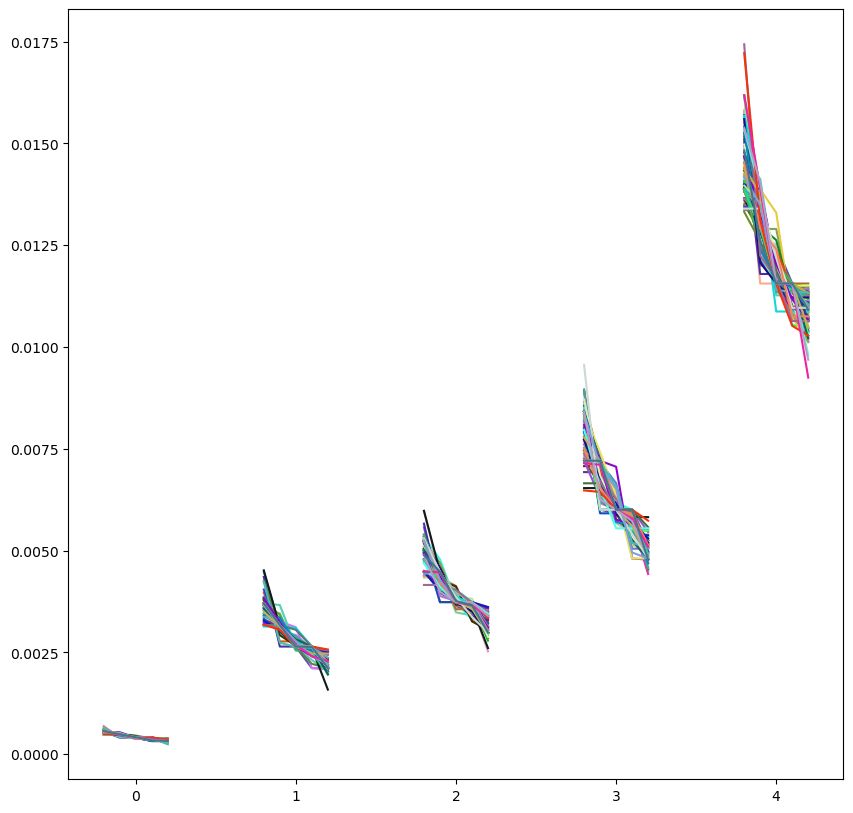

In [124]:
fig, ax = plt.subplots(figsize=(10, 10))

for results_dir in results_dirs_to_merge:
    # Pick out coeffs:
    coeffs = df_best_gens.filter(df_best_gens['dir'] == results_dir)[coeff_names].to_numpy().flatten()
    # if results_dir in df_best_gens_topr2['dir']:
    colour = np.random.rand(3,)
    zorder = 5
    alpha = 1.0
    # else:
    #     colour = 'silver'
    #     zorder = 4
    #     alpha = 0.4
    # g = gen_attr(df_coeffs_init)

    offset = -0.2
    for c in range(5):
        # xs = np.arange(5) + offset
        # ys = g[c*5:(c*5)+5]
        xs = np.arange(-0.2, 0.3, 0.1) + c
        
        ys = np.array(coeffs)[np.arange(0, 25, 5) + c] * np.array([coeffs_ssnap[c]] * 5)
        ax.plot(xs, ys, color=colour, zorder=zorder, alpha=alpha, label=(results_dir if c==0 else None))
        offset += 0.1
plt.show()

In [125]:
for results_dir in results_dirs_to_merge:
    # Pick out coeffs:
    coeffs = df_best_gens.filter(df_best_gens['dir'] == results_dir)[coeff_names].to_numpy().flatten()
    
    ys = np.array(coeffs).reshape(5, 5)
    print(np.round(ys, 5))
    print('')

[[1.45024 1.50281 1.34539 1.20882 1.22821]
 [1.13677 1.04781 1.2     1.15248 1.1956 ]
 [0.95171 1.04781 1.      1.00087 1.00384]
 [0.94883 0.99339 1.      1.      0.97503]
 [0.8     0.8     0.8     0.82731 0.93872]]

[[1.3725  1.33718 1.42999 1.23686 1.36543]
 [1.2     1.27244 1.08608 1.2     1.05242]
 [1.      1.      1.00963 0.98854 1.     ]
 [0.90955 0.98081 0.92828 0.98854 0.97681]
 [0.8     0.8     0.89044 0.79856 0.97681]]

[[1.34794 1.4     1.32982 1.33947 1.29352]
 [1.2     1.2     1.2     1.2     1.05639]
 [1.02472 1.      0.9807  1.      1.     ]
 [0.92125 1.      0.94315 0.95035 1.     ]
 [0.8     0.79475 0.90809 0.75115 0.97835]]

[[1.50034 1.27488 1.42816 1.36482 1.21037]
 [1.12027 1.23616 1.06131 1.      1.2    ]
 [0.99967 1.05311 1.02379 1.      1.     ]
 [0.84039 1.      1.02379 0.92934 1.     ]
 [0.81307 0.8     0.8     0.92179 0.93287]]

[[1.46312 1.69516 1.20555 1.19339 1.20279]
 [1.19011 1.18346 1.2     1.19339 1.10153]
 [0.96069 0.99798 1.      1.      1.08078]
 [0

In [102]:
for results_dir in results_dirs_to_merge:
    # Pick out coeffs:
    coeffs = df_best_gens.filter(df_best_gens['dir'] == results_dir)[coeff_names].to_numpy().flatten()
    
    ys = np.array(coeffs).reshape(5, 5)
    print(np.round(ys, 5))
    print('')

[[1.54653 1.37719 1.3851  0.88937 1.238  ]
 [1.29861 1.20074 0.94144 0.88937 1.1956 ]
 [1.      0.84772 0.79464 0.88871 1.1956 ]
 [0.98693 0.54453 0.69055 0.84934 1.15131]
 [0.66711 0.54453 0.6431  0.79574 1.15131]]

[[1.52518 1.20722 1.24561 0.77475 1.38901]
 [1.30452 1.1896  1.02377 0.77475 1.20754]
 [1.      0.90593 0.87838 0.77475 1.2    ]
 [0.96701 0.80289 0.72441 0.76098 1.11932]
 [0.69478 0.69589 0.68483 0.73808 1.11932]]

[[1.55468 1.38925 1.36959 0.93584 1.2204 ]
 [1.33646 1.05118 0.88599 0.90223 1.2204 ]
 [1.01699 0.83043 0.7084  0.90223 1.2204 ]
 [0.97918 0.36913 0.59093 0.89586 1.2    ]
 [0.70981 0.36913 0.58186 0.7597  1.2    ]]

[[1.56527 1.48056 1.38408 0.89434 1.21003]
 [1.31356 1.21205 0.95472 0.81962 1.21003]
 [0.99499 1.01893 0.73616 0.81962 1.21003]
 [0.99499 0.52686 0.73616 0.78243 1.16316]
 [0.6532  0.52686 0.69189 0.75765 1.16316]]

[[1.55647 1.66274 1.25567 0.89819 1.20825]
 [1.29742 1.20942 0.87452 0.89819 1.20825]
 [1.      0.75041 0.82554 0.89819 1.19904]
 [1

In [114]:
for results_dir in results_dirs_to_merge:
    # Pick out coeffs:
    coeffs = df_best_gens.filter(df_best_gens['dir'] == results_dir)[coeff_names].to_numpy().flatten()
    
    ys = np.array(coeffs).reshape(5, 5) * coeffs_ssnap
    print(np.round(ys, 5))
    print('')

[[0.00059 0.00397 0.00503 0.00726 0.0142 ]
 [0.00046 0.00277 0.00448 0.00692 0.01382]
 [0.00039 0.00277 0.00374 0.00601 0.0116 ]
 [0.00039 0.00263 0.00374 0.006   0.01127]
 [0.00033 0.00212 0.00299 0.00497 0.01085]]

[[0.00056 0.00354 0.00534 0.00743 0.01578]
 [0.00049 0.00336 0.00406 0.00721 0.01216]
 [0.00041 0.00264 0.00377 0.00594 0.01156]
 [0.00037 0.00259 0.00347 0.00594 0.01129]
 [0.00033 0.00212 0.00333 0.0048  0.01129]]

[[0.00055 0.0037  0.00497 0.00804 0.01495]
 [0.00049 0.00317 0.00448 0.00721 0.01221]
 [0.00042 0.00264 0.00366 0.006   0.01156]
 [0.00038 0.00264 0.00352 0.00571 0.01156]
 [0.00033 0.0021  0.00339 0.00451 0.01131]]

[[0.00061 0.00337 0.00533 0.0082  0.01399]
 [0.00046 0.00327 0.00396 0.006   0.01387]
 [0.00041 0.00278 0.00382 0.006   0.01156]
 [0.00034 0.00264 0.00382 0.00558 0.01156]
 [0.00033 0.00212 0.00299 0.00554 0.01078]]

[[0.0006  0.00448 0.0045  0.00717 0.0139 ]
 [0.00049 0.00313 0.00448 0.00717 0.01273]
 [0.00039 0.00264 0.00374 0.006   0.01249]
 [0

In [100]:
for results_dir in results_dirs_to_merge:
    # Pick out coeffs:
    coeffs = df_best_gens.filter(df_best_gens['dir'] == results_dir)[coeff_names].to_numpy().flatten()
    
    ys = np.array(coeffs).reshape(5, 5) * coeffs_ssnap
    print(np.round(ys, 5))
    print('')

[[0.00063 0.00364 0.00517 0.00534 0.01431]
 [0.00053 0.00317 0.00352 0.00534 0.01382]
 [0.00041 0.00224 0.00297 0.00534 0.01382]
 [0.0004  0.00144 0.00258 0.0051  0.01331]
 [0.00027 0.00144 0.0024  0.00478 0.01331]]

[[0.00062 0.00319 0.00465 0.00465 0.01605]
 [0.00053 0.00315 0.00382 0.00465 0.01396]
 [0.00041 0.0024  0.00328 0.00465 0.01387]
 [0.00039 0.00212 0.00271 0.00457 0.01294]
 [0.00028 0.00184 0.00256 0.00443 0.01294]]

[[0.00063 0.00367 0.00512 0.00562 0.01411]
 [0.00055 0.00278 0.00331 0.00542 0.01411]
 [0.00041 0.0022  0.00265 0.00542 0.01411]
 [0.0004  0.00098 0.00221 0.00538 0.01387]
 [0.00029 0.00098 0.00217 0.00456 0.01387]]

[[0.00064 0.00391 0.00517 0.00537 0.01399]
 [0.00054 0.0032  0.00357 0.00492 0.01399]
 [0.00041 0.00269 0.00275 0.00492 0.01399]
 [0.00041 0.00139 0.00275 0.0047  0.01344]
 [0.00027 0.00139 0.00258 0.00455 0.01344]]

[[0.00064 0.0044  0.00469 0.00539 0.01396]
 [0.00053 0.0032  0.00327 0.00539 0.01396]
 [0.00041 0.00198 0.00308 0.00539 0.01386]
 [0

In [101]:
coeffs_ssnap

[0.000408, 0.002644, 0.003735, 0.006005, 0.011558]

## Load admissions data

In [10]:
path_to_msoa_stats = os.path.join('..', 'data', 'msoa_cleaned.csv')

df_stats = pl.read_csv(path_to_msoa_stats)

In [11]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662


Check sum of admissions for Welsh areas:

In [12]:
df_stats.filter(df_stats['country'] == 'W')['admissions'].sum()

0.0

Welsh data is always zero so remove it.

In [13]:
df_stats = df_stats.filter(df_stats['country'] != 'W')

Recalculate total numbers of patients:

In [14]:
df_stats = df_stats.with_columns((pl.col('good_health') + pl.col('fair health') + pl.col('bad health')).alias('total_health'))

In [15]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion,total_health
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64,i64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062,8524
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692,6634
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661,7100
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638,10127
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662,8526


Pick out column names for the health and age proportions:

In [16]:
health_numbers = ['good_health', 'fair health', 'bad health']
props_health = ['prop_good_health', 'prop_fair health', 'prop_bad health']
props_age = [
    'age_less65_proportion', 'age_65_proportion', 'age_70_proportion',
    'age_75_proportion', 'age_over80_proportion'
]

Calculate numbers of patients in each age band:

In [17]:
age_numbers = []

for col in props_age:
    new_col = col.replace('_proportion', '')
    age_numbers.append(new_col)
    df_stats = df_stats.with_columns((pl.col(col) * pl.col('total_health')).alias(new_col))

In [18]:
df_stats[['total_health'] + props_age + age_numbers].head()

total_health,age_less65_proportion,age_65_proportion,age_70_proportion,age_75_proportion,age_over80_proportion,age_less65,age_65,age_70,age_75,age_over80
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
8524,0.7872,0.0559,0.0528,0.0422,0.062,6710.0928,476.4916,450.0672,359.7128,528.488
6634,0.7467,0.0578,0.0774,0.0492,0.0692,4953.6078,383.4452,513.4716,326.3928,459.0728
7100,0.7729,0.0609,0.0582,0.0421,0.0661,5487.59,432.39,413.22,298.91,469.31
10127,0.8091,0.0465,0.0438,0.0367,0.0638,8193.7557,470.9055,443.5626,371.6609,646.1026
8526,0.7643,0.0597,0.067,0.0425,0.0662,6516.4218,509.0022,571.242,362.355,564.4212


## Set up bins for IMD scores

Use quantiles so that each bin contains 10% of the MSOA (to match plot notebook).

The resulting dictionary has keys for which quantile it is and values for the left side (smaller, minimum value in bin) of the IMD bin.

In [19]:
dict_quantiles = {}

for q in np.arange(0.0, 1.01, 0.2):
    v = df_stats['IMD2019Score'].quantile(q)
    # Flip the ranking because lower rank (more deprived) should be for
    # higher IMD scores (more deprived).
    q_store = 1.0 - q
    dict_quantiles[round(q_store, 1)] = round(v, 5)

In [20]:
dict_quantiles

{1.0: 2.2122,
 0.8: 10.369,
 0.6: 15.2564,
 0.4: 21.81475,
 0.2: 31.84075,
 0.0: 87.02675}

In [21]:
qmin_list = sorted(dict_quantiles.keys())[:-1]

In [22]:
qmin_list

[0.0, 0.2, 0.4, 0.6, 0.8]

Pick out just the values for the left edges of the bins:

In [23]:
imd_bin_left_edges = {}
for k in list(dict_quantiles.keys())[:-1]:
    imd_bin_left_edges[k] = dict_quantiles[k]

In [24]:
imd_bin_left_edges

{1.0: 2.2122, 0.8: 10.369, 0.6: 15.2564, 0.4: 21.81475, 0.2: 31.84075}

Place MSOA into these bins:

In [25]:
# Make columns for the results with a placeholder value:
# df_stats = df_stats.with_columns(pl.lit(0).alias('imd_bin_min'))
# df_stats = df_stats.with_columns(pl.lit(0).alias('imd_bin_max'))
df_stats = df_stats.with_columns(pl.lit(0.0).alias('depriv_quantile_min'))
df_stats = df_stats.with_columns(pl.lit(0.0).alias('depriv_quantile_max'))

for q, quantile in enumerate(list(dict_quantiles.keys())[:-1]):
    # Pick out the bin edges:
    qmin = list(dict_quantiles.keys())[q+1]
    q0 = dict_quantiles[quantile]
    q1 = dict_quantiles[qmin]
    # Find a mask for the demographic data that contains
    # only MSOA with IMD scores in this bin.
    mask = (df_stats['IMD2019Score'] >= q0) & (df_stats['IMD2019Score'] < q1)
    if q == len(dict_quantiles) - 2:
        # Also allow values at the right edge of the final bin.
        mask = mask | (df_stats['IMD2019Score'] == q1)

    # Update the bin min/max values for these rows:
    df_stats = df_stats.with_columns(
        pl.when((mask))
        .then(qmin)         # replace with bin min
        .otherwise(pl.col('depriv_quantile_min'))  # otherwise keep the existing value
        .name.keep()
    )
    df_stats = df_stats.with_columns(
        pl.when((mask))
        .then(quantile)         # replace with bin min
        .otherwise(pl.col('depriv_quantile_max'))  # otherwise keep the existing value
        .name.keep()
    )

Check that data was binned correctly:

In [26]:
df_stats[['IMD2019Score', 'depriv_quantile_min', 'depriv_quantile_max']]

IMD2019Score,depriv_quantile_min,depriv_quantile_max
f64,f64,f64
16.924833,0.4,0.6
6.4704,0.8,1.0
13.7334,0.6,0.8
26.199857,0.2,0.4
11.7948,0.6,0.8
…,…,…
3.25925,0.8,1.0
7.29475,0.8,1.0
12.117,0.6,0.8


In [27]:
qmin_list = np.round(np.arange(0.0, 1.0, 0.2), 1)

In [28]:
# Names of coeffs:
coeff_names = [f'{a}_q{str(round(q, 1)).replace(".", "")}' for q in qmin_list for a in age_numbers]

coeff_names

['age_less65_q00',
 'age_65_q00',
 'age_70_q00',
 'age_75_q00',
 'age_over80_q00',
 'age_less65_q02',
 'age_65_q02',
 'age_70_q02',
 'age_75_q02',
 'age_over80_q02',
 'age_less65_q04',
 'age_65_q04',
 'age_70_q04',
 'age_75_q04',
 'age_over80_q04',
 'age_less65_q06',
 'age_65_q06',
 'age_70_q06',
 'age_75_q06',
 'age_over80_q06',
 'age_less65_q08',
 'age_65_q08',
 'age_70_q08',
 'age_75_q08',
 'age_over80_q08']

In [29]:
admissions_lists = []
x_lists = []

for qmin in qmin_list:
    df_stats_here = df_stats.filter(df_stats['depriv_quantile_min'] == qmin)
    # MSOA data in the same order as those coefficients:
    x_lists_here = [df_stats_here[a] for a in age_numbers]
    admissions_here = df_stats_here['admissions'].to_numpy().tolist()
    # Store:
    admissions_lists.append(admissions_here)
    x_lists.append(x_lists_here)

In [30]:
# from previous notebook
coeffs_ssnap = [0.000408, 0.002644, 0.003735, 0.006005, 0.011558]

## Calculate r-squared

In [31]:
def predict_admissions(x_lists, coeffs):
    """
    x_lists: np.array.
    coeffs: np.array.
    
    Have to have same number of coeffs as x_lists.
    """
    # Predicted admissions:
    # yhat = (x_lists * coeffs.reshape(len(coeffs), 1)).sum(axis=0)
    yhat = sum(
        [x_lists[i] * coeffs[i] for i in range(len(coeffs))]
    )
    return yhat.to_numpy().tolist()

In [32]:
def calculate_rsquared(y, yhat):
    """This gives the same results as the sklearn built-in."""
    y = np.array(y)
    yhat = np.array(yhat)
    y_mean = np.mean(y)#.mean()
    ss_res = np.sum(((yhat - y)**2.0))#.sum()
    ss_tot = np.sum(((y - y_mean)**2.0))#.sum()
    if ss_tot != 0.0:
        rsq = 1.0 - ss_res / ss_tot
    else:
        rsq = np.NaN
    return rsq

In [33]:
def calculate_many_rsquared(coeffs, x_lists, coeffs_ssnap, admissions_lists):
    list_r2 = []
    predictions_lists = []
    for i in range(5):
        # Population numbers for areas in this quantile:
        x_lists_here = x_lists[i]
        # Separate prediction for each deprivation quantile:
        c = np.array(coeffs[(i*5):(i*5)+5]) * np.array(coeffs_ssnap)
        yhat = predict_admissions(x_lists_here, c)
        predictions_lists.append(yhat)
        observed_here = admissions_lists[i]
        r2 = calculate_rsquared(observed_here, yhat)
        list_r2.append(r2)

    # Combine lists:
    observed_all = sum(admissions_lists, [])
    predicted_all = sum(predictions_lists, [])
    # Calculate r-squared:
    r2 = calculate_rsquared(observed_all, predicted_all)
    list_r2.append(r2)
    return list_r2

In [126]:
dict_r2 = {}
dict_r2_qs = [{}, {}, {}, {}, {}]

for results_dir in results_dirs_to_merge:
    # Pick out coeffs:
    coeffs = df_best_gens.filter(df_best_gens['dir'] == results_dir)[coeff_names].to_numpy().flatten()

    list_r2 = calculate_many_rsquared(coeffs, x_lists, coeffs_ssnap, admissions_lists)
    for i in range(len(dict_r2_qs)):
        dict_r2_qs[i][results_dir] = list_r2[i]
    dict_r2[results_dir] = list_r2[-1]

In [127]:
df_r2 = pl.from_dict(dict_r2).transpose(include_header=True).rename({'column': 'dir', 'column_0': 'r2_all'})
df_r2_q00 = pl.from_dict(dict_r2_qs[0]).transpose(include_header=True).rename({'column': 'dir', 'column_0': 'r2_q00'})
df_r2_q02 = pl.from_dict(dict_r2_qs[1]).transpose(include_header=True).rename({'column': 'dir', 'column_0': 'r2_q02'})
df_r2_q04 = pl.from_dict(dict_r2_qs[2]).transpose(include_header=True).rename({'column': 'dir', 'column_0': 'r2_q04'})
df_r2_q06 = pl.from_dict(dict_r2_qs[3]).transpose(include_header=True).rename({'column': 'dir', 'column_0': 'r2_q06'})
df_r2_q08 = pl.from_dict(dict_r2_qs[4]).transpose(include_header=True).rename({'column': 'dir', 'column_0': 'r2_q08'})

In [128]:
for df in [df_r2, df_r2_q00, df_r2_q02, df_r2_q04, df_r2_q06, df_r2_q08]:
    df_best_gens = df_best_gens.join(df, on='dir')

In [129]:
df_best_gens.sort('r2_all', descending=True)

dir,# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness,r2_all,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed04""",59.0,1.46312,1.695159,1.205551,1.19339,1.202789,1.19011,1.183463,1.2,1.19339,1.10153,0.960694,0.997975,1.0,1.0,1.080779,0.85047,0.799606,0.974258,0.998259,1.0,0.808107,0.793863,0.899786,0.8,0.930343,239.287371,0.59191,0.496018,0.579529,0.638646,0.607951,0.615709
"""randomseed41""",35.0,1.4,1.394472,1.491289,1.2,1.176441,1.253797,1.173068,1.080715,1.050118,1.125261,1.0,1.053346,1.0,1.0,1.0,0.8,0.961484,1.0,1.0,1.0,0.8,0.8,0.8,0.908886,0.982146,240.136292,0.591804,0.494457,0.58296,0.634319,0.606642,0.619415
"""randomseed47""",51.0,1.509935,1.288461,1.327035,1.33879,1.2,1.113402,1.198,1.2,1.125237,1.12347,0.992264,1.05886,1.0,1.016319,1.0,0.902984,0.926627,0.939284,0.958704,0.988581,0.755995,0.889544,0.863378,0.819027,0.988581,240.268793,0.591575,0.494178,0.579535,0.634652,0.607894,0.620379
"""randomseed65""",58.0,1.384298,1.707645,1.6,1.088252,1.180937,1.202216,1.18193,1.2,1.088252,1.110136,0.988208,1.0,1.0,1.0,1.019277,0.912351,0.987298,0.96661,0.970934,0.99073,0.79201,0.6,0.697933,0.969452,0.981982,240.477538,0.591558,0.494306,0.581535,0.635265,0.605752,0.619604
"""randomseed81""",30.0,1.474497,1.4,1.4,1.107886,1.2,1.106899,1.2,1.183136,1.107886,1.184099,0.995979,1.0,1.0,1.0,1.02665,0.89788,0.974566,0.993429,1.0,0.950901,0.799854,0.790744,0.8,0.928723,0.950901,241.679306,0.591511,0.496688,0.577989,0.636342,0.606189,0.619144
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""randomseed60""",23.0,1.4,1.391014,1.4,1.4,1.269015,1.187818,1.2,1.2,1.2,1.2,1.0,1.0,0.977735,1.0,1.0,0.890014,1.0,0.977735,0.880251,0.942276,0.795935,0.8,0.8,0.8,0.927973,241.734051,0.58279,0.486058,0.562332,0.632282,0.602063,0.609088
"""randomseed83""",25.0,1.322617,1.350996,1.341558,1.4,1.278371,1.155608,1.2,1.2,1.2,1.184784,1.0,1.067706,1.0,0.9933,1.0,1.0,1.0,0.994465,0.874328,1.0,0.8,0.741061,0.8,0.8,0.883632,243.415986,0.581689,0.491031,0.56937,0.63435,0.60288,0.588041
"""randomseed98""",34.0,1.4,1.385308,1.309416,1.4,1.32992,1.2,1.2,1.068135,1.041676,1.215415,1.0,1.0,1.0,1.0,0.999982,0.868196,1.0,1.0,0.953337,0.999399,0.8,0.80838,0.909831,0.8,0.838122,243.918821,0.581656,0.481074,0.578695,0.63315,0.605913,0.585607


In [130]:
r2_best = df_best_gens['r2_all'].max()

r2_best

0.5919103791585711

In [131]:
df_best_gens_topr2 = df_best_gens.filter(np.round(df_best_gens['r2_all'], 3) == np.round(r2_best, 3)).sort('r2_all', descending=True)

In [132]:
df_best_gens_topr2.select(pl.col(float).round(2))

# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness,r2_all,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
59.0,1.46,1.7,1.21,1.19,1.2,1.19,1.18,1.2,1.19,1.1,0.96,1.0,1.0,1.0,1.08,0.85,0.8,0.97,1.0,1.0,0.81,0.79,0.9,0.8,0.93,239.29,0.59,0.5,0.58,0.64,0.61,0.62
35.0,1.4,1.39,1.49,1.2,1.18,1.25,1.17,1.08,1.05,1.13,1.0,1.05,1.0,1.0,1.0,0.8,0.96,1.0,1.0,1.0,0.8,0.8,0.8,0.91,0.98,240.14,0.59,0.49,0.58,0.63,0.61,0.62
51.0,1.51,1.29,1.33,1.34,1.2,1.11,1.2,1.2,1.13,1.12,0.99,1.06,1.0,1.02,1.0,0.9,0.93,0.94,0.96,0.99,0.76,0.89,0.86,0.82,0.99,240.27,0.59,0.49,0.58,0.63,0.61,0.62
58.0,1.38,1.71,1.6,1.09,1.18,1.2,1.18,1.2,1.09,1.11,0.99,1.0,1.0,1.0,1.02,0.91,0.99,0.97,0.97,0.99,0.79,0.6,0.7,0.97,0.98,240.48,0.59,0.49,0.58,0.64,0.61,0.62
30.0,1.47,1.4,1.4,1.11,1.2,1.11,1.2,1.18,1.11,1.18,1.0,1.0,1.0,1.0,1.03,0.9,0.97,0.99,1.0,0.95,0.8,0.79,0.8,0.93,0.95,241.68,0.59,0.5,0.58,0.64,0.61,0.62


In [133]:
len(df_best_gens_topr2)

5

In [134]:
df_best_gens_topr2.mean().select(pl.col(float).round(2))

# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness,r2_all,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
46.6,1.45,1.5,1.4,1.19,1.19,1.17,1.19,1.17,1.11,1.13,0.99,1.02,1.0,1.0,1.03,0.87,0.93,0.97,0.99,0.99,0.79,0.77,0.81,0.89,0.97,240.37,0.59,0.5,0.58,0.64,0.61,0.62


In [135]:
df_best_gens_topr2.std().select(pl.col(float).round(2))

# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness,r2_all,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
13.35,0.05,0.19,0.15,0.1,0.01,0.06,0.01,0.05,0.05,0.03,0.02,0.03,0.0,0.01,0.03,0.05,0.08,0.02,0.02,0.02,0.02,0.11,0.08,0.07,0.03,0.86,0.0,0.0,0.0,0.0,0.0,0.0


In [136]:
df_best_gens_topr2.min().select(pl.col(float).round(2))

# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness,r2_all,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
30.0,1.38,1.29,1.21,1.09,1.18,1.11,1.17,1.08,1.05,1.1,0.96,1.0,1.0,1.0,1.0,0.8,0.8,0.94,0.96,0.95,0.76,0.6,0.7,0.8,0.93,239.29,0.59,0.49,0.58,0.63,0.61,0.62


In [137]:
df_best_gens_topr2.max().select(pl.col(float).round(2))

# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness,r2_all,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
59.0,1.51,1.71,1.6,1.34,1.2,1.25,1.2,1.2,1.19,1.18,1.0,1.06,1.0,1.02,1.08,0.91,0.99,1.0,1.0,1.0,0.81,0.89,0.9,0.97,0.99,241.68,0.59,0.5,0.58,0.64,0.61,0.62


In [138]:
import matplotlib.pyplot as plt

In [139]:
coeff_names

['age_less65_q00',
 'age_65_q00',
 'age_70_q00',
 'age_75_q00',
 'age_over80_q00',
 'age_less65_q02',
 'age_65_q02',
 'age_70_q02',
 'age_75_q02',
 'age_over80_q02',
 'age_less65_q04',
 'age_65_q04',
 'age_70_q04',
 'age_75_q04',
 'age_over80_q04',
 'age_less65_q06',
 'age_65_q06',
 'age_70_q06',
 'age_75_q06',
 'age_over80_q06',
 'age_less65_q08',
 'age_65_q08',
 'age_70_q08',
 'age_75_q08',
 'age_over80_q08']

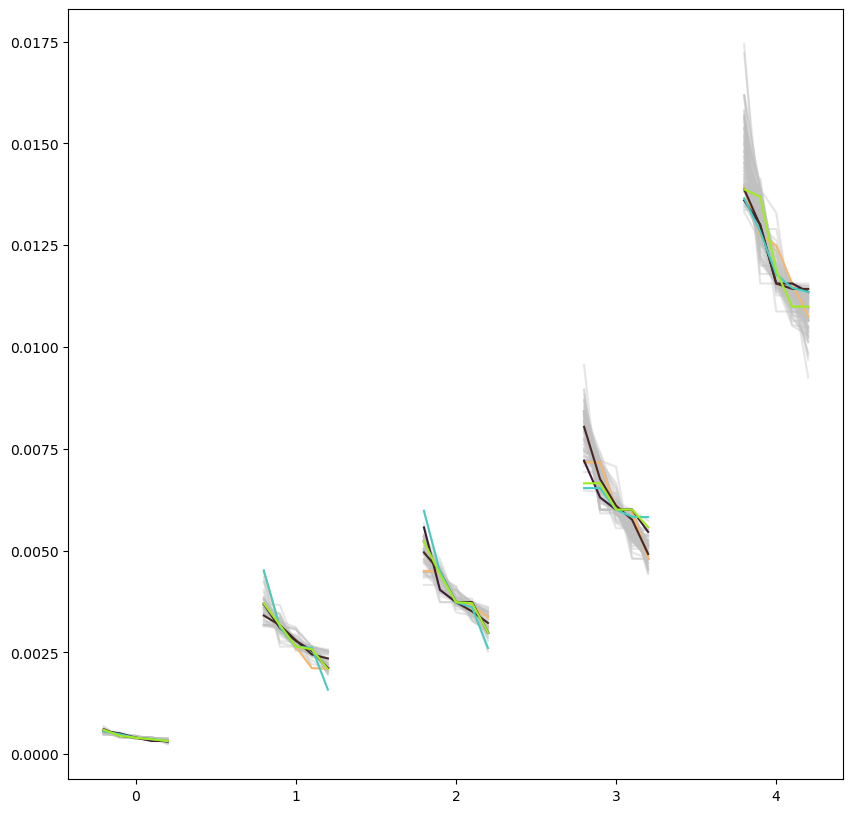

In [140]:
fig, ax = plt.subplots(figsize=(10, 10))

for results_dir in results_dirs:
    # Pick out coeffs:
    coeffs = df_best_gens.filter(df_best_gens['dir'] == results_dir)[coeff_names].to_numpy().flatten()
    if results_dir in df_best_gens_topr2['dir']:
        colour = np.random.rand(3,)
        zorder = 5
        alpha = 1.0
    else:
        colour = 'silver'
        zorder = 4
        alpha = 0.4
    # g = gen_attr(df_coeffs_init)

    offset = -0.2
    for c in range(5):
        # xs = np.arange(5) + offset
        # ys = g[c*5:(c*5)+5]
        xs = np.arange(-0.2, 0.3, 0.1) + c
        
        ys = np.array(coeffs)[np.arange(0, 25, 5) + c] * np.array([coeffs_ssnap[c]] * 5)
        ax.plot(xs, ys, color=colour, zorder=zorder, alpha=alpha, label=(results_dir if c==0 else None))
        offset += 0.1
plt.show()

## CHECK ROUNDED COEFF R-SQUARED.

In [141]:
n_dig = 2

dict_r2 = {}
dict_r2_qs = [{}, {}, {}, {}, {}]

for results_dir in results_dirs_to_merge:
    # Pick out coeffs:
    coeffs = np.round(df_best_gens.filter(df_best_gens['dir'] == results_dir)[coeff_names].to_numpy().flatten(), n_dig)

    list_r2 = calculate_many_rsquared(coeffs, x_lists, coeffs_ssnap, admissions_lists)
    for i in range(len(dict_r2_qs)):
        dict_r2_qs[i][results_dir] = list_r2[i]
    dict_r2[results_dir] = list_r2[-1]

df_r2 = pl.from_dict(dict_r2).transpose(include_header=True).rename({'column': 'dir', 'column_0': 'r2_all_round'})
df_r2_q00 = pl.from_dict(dict_r2_qs[0]).transpose(include_header=True).rename({'column': 'dir', 'column_0': 'r2_q00_round'})
df_r2_q02 = pl.from_dict(dict_r2_qs[1]).transpose(include_header=True).rename({'column': 'dir', 'column_0': 'r2_q02_round'})
df_r2_q04 = pl.from_dict(dict_r2_qs[2]).transpose(include_header=True).rename({'column': 'dir', 'column_0': 'r2_q04_round'})
df_r2_q06 = pl.from_dict(dict_r2_qs[3]).transpose(include_header=True).rename({'column': 'dir', 'column_0': 'r2_q06_round'})
df_r2_q08 = pl.from_dict(dict_r2_qs[4]).transpose(include_header=True).rename({'column': 'dir', 'column_0': 'r2_q08_round'})

df_best_gens_round = df_best_gens

for col in coeff_names:
    df_best_gens_round = df_best_gens_round.with_columns(pl.col(col).round(n_dig))

for df in [df_r2, df_r2_q00, df_r2_q02, df_r2_q04, df_r2_q06, df_r2_q08]:
    df_best_gens_round = df_best_gens_round.join(df, on='dir')

In [142]:
df_best_gens_round.sort('r2_all_round', descending=True)

dir,# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness,r2_all,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08,r2_all_round,r2_q00_round,r2_q02_round,r2_q04_round,r2_q06_round,r2_q08_round
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed04""",59.0,1.46,1.7,1.21,1.19,1.2,1.19,1.18,1.2,1.19,1.1,0.96,1.0,1.0,1.0,1.08,0.85,0.8,0.97,1.0,1.0,0.81,0.79,0.9,0.8,0.93,239.287371,0.59191,0.496018,0.579529,0.638646,0.607951,0.615709,0.591965,0.496126,0.579794,0.638634,0.607939,0.61564
"""randomseed41""",35.0,1.4,1.39,1.49,1.2,1.18,1.25,1.17,1.08,1.05,1.13,1.0,1.05,1.0,1.0,1.0,0.8,0.96,1.0,1.0,1.0,0.8,0.8,0.8,0.91,0.98,240.136292,0.591804,0.494457,0.58296,0.634319,0.606642,0.619415,0.591811,0.494526,0.582932,0.634255,0.606659,0.619472
"""randomseed81""",30.0,1.47,1.4,1.4,1.11,1.2,1.11,1.2,1.18,1.11,1.18,1.0,1.0,1.0,1.0,1.03,0.9,0.97,0.99,1.0,0.95,0.8,0.79,0.8,0.93,0.95,241.679306,0.591511,0.496688,0.577989,0.636342,0.606189,0.619144,0.591642,0.496593,0.578275,0.636747,0.606232,0.619101
"""randomseed65""",58.0,1.38,1.71,1.6,1.09,1.18,1.2,1.18,1.2,1.09,1.11,0.99,1.0,1.0,1.0,1.02,0.91,0.99,0.97,0.97,0.99,0.79,0.6,0.7,0.97,0.98,240.477538,0.591558,0.494306,0.581535,0.635265,0.605752,0.619604,0.591548,0.494351,0.581525,0.635425,0.605742,0.619345
"""randomseed17""",42.0,1.4,1.4,1.31,1.15,1.27,1.2,1.2,1.18,1.15,1.1,1.03,1.0,1.04,1.0,1.0,0.84,1.0,1.0,1.0,0.99,0.8,0.81,0.8,0.86,0.96,239.511398,0.591435,0.495291,0.580508,0.635369,0.605874,0.618868,0.591519,0.495292,0.580849,0.635368,0.605704,0.619128
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""randomseed60""",23.0,1.4,1.39,1.4,1.4,1.27,1.19,1.2,1.2,1.2,1.2,1.0,1.0,0.98,1.0,1.0,0.89,1.0,0.98,0.88,0.94,0.8,0.8,0.8,0.8,0.93,241.734051,0.58279,0.486058,0.562332,0.632282,0.602063,0.609088,0.582843,0.485949,0.562048,0.632376,0.60171,0.610026
"""randomseed98""",34.0,1.4,1.39,1.31,1.4,1.33,1.2,1.2,1.07,1.04,1.22,1.0,1.0,1.0,1.0,1.0,0.87,1.0,1.0,0.95,1.0,0.8,0.81,0.91,0.8,0.84,243.918821,0.581656,0.481074,0.578695,0.63315,0.605913,0.585607,0.58171,0.480813,0.578134,0.633153,0.605935,0.586695
"""randomseed83""",25.0,1.32,1.35,1.34,1.4,1.28,1.16,1.2,1.2,1.2,1.18,1.0,1.07,1.0,0.99,1.0,1.0,1.0,0.99,0.87,1.0,0.8,0.74,0.8,0.8,0.88,243.415986,0.581689,0.491031,0.56937,0.63435,0.60288,0.588041,0.581515,0.490981,0.56993,0.634277,0.603419,0.586117


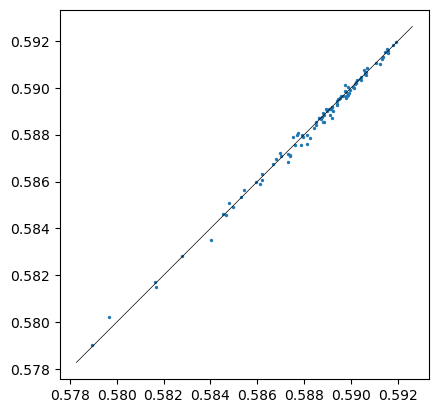

In [143]:
fig, ax = plt.subplots()

ax.scatter(df_best_gens_round['r2_all'], df_best_gens_round['r2_all_round'], s=2)
ax.set_aspect('equal')
zmin = min(ax.get_xlim()[0], ax.get_ylim()[0])
zmax = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([zmin, zmax], [zmin, zmax], color='k', linewidth=0.5)

plt.show()

In [144]:
best_r2_round = df_best_gens_round['r2_all_round'].max()

best_r2_round

0.5919646089051904

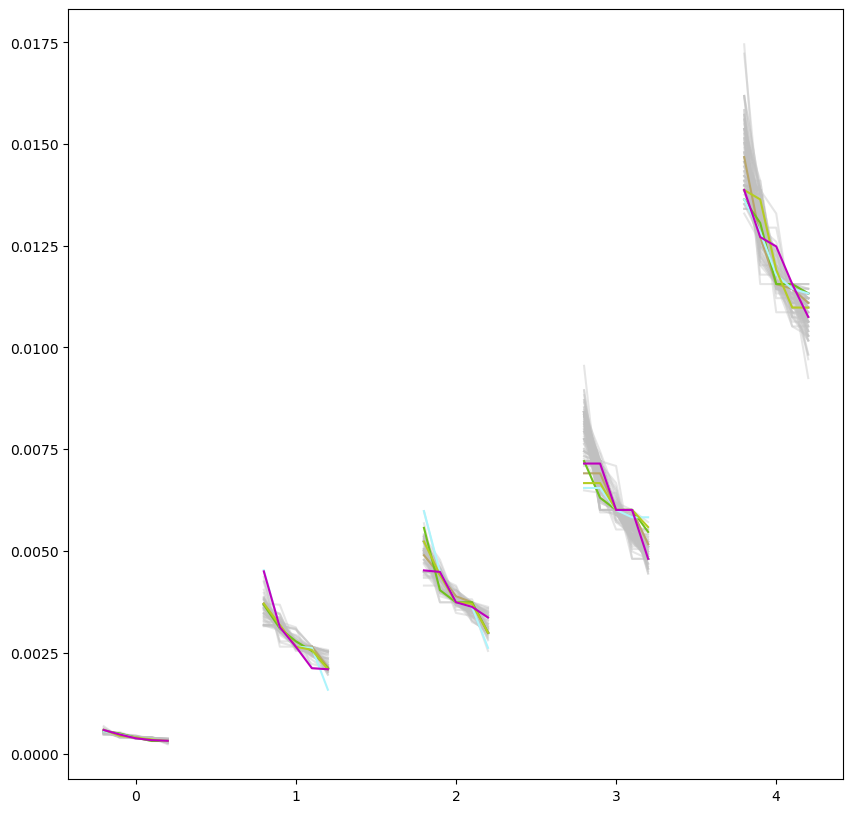

In [145]:
fig, ax = plt.subplots(figsize=(10, 10))

for results_dir in results_dirs:
    # Pick out coeffs:
    coeffs = df_best_gens_round.filter(df_best_gens_round['dir'] == results_dir)[coeff_names].to_numpy().flatten()
    r2 = df_best_gens_round.filter(df_best_gens_round['dir'] == results_dir)['r2_all_round'].to_numpy()[0]
    if round(r2, 3) == round(best_r2_round, 3):
        if r2 == best_r2_round:
            colour = 'm'
            zorder=6
        else:
            colour = np.random.rand(3,)
            zorder = 5
        alpha = 1.0
    else:
        colour = 'silver'
        zorder = 4
        alpha = 0.4
    # g = gen_attr(df_coeffs_init)

    offset = -0.2
    for c in range(5):
        # xs = np.arange(5) + offset
        # ys = g[c*5:(c*5)+5]
        xs = np.arange(-0.2, 0.3, 0.1) + c
        
        ys = np.array(coeffs)[np.arange(0, 25, 5) + c] * np.array([coeffs_ssnap[c]] * 5)
        ax.plot(xs, ys, color=colour, zorder=zorder, alpha=alpha, label=(results_dir if c==0 else None))
        offset += 0.1
plt.show()

In [146]:
with pl.Config(tbl_rows=50):
    display(df_best_gens_round.filter(df_best_gens_round['r2_all_round'].round(3) == round(best_r2_round, 3)).sort('r2_all_round', descending=True))

dir,# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness,r2_all,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08,r2_all_round,r2_q00_round,r2_q02_round,r2_q04_round,r2_q06_round,r2_q08_round
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed04""",59.0,1.46,1.7,1.21,1.19,1.2,1.19,1.18,1.2,1.19,1.1,0.96,1.0,1.0,1.0,1.08,0.85,0.8,0.97,1.0,1.0,0.81,0.79,0.9,0.8,0.93,239.287371,0.59191,0.496018,0.579529,0.638646,0.607951,0.615709,0.591965,0.496126,0.579794,0.638634,0.607939,0.61564
"""randomseed41""",35.0,1.4,1.39,1.49,1.2,1.18,1.25,1.17,1.08,1.05,1.13,1.0,1.05,1.0,1.0,1.0,0.8,0.96,1.0,1.0,1.0,0.8,0.8,0.8,0.91,0.98,240.136292,0.591804,0.494457,0.58296,0.634319,0.606642,0.619415,0.591811,0.494526,0.582932,0.634255,0.606659,0.619472
"""randomseed81""",30.0,1.47,1.4,1.4,1.11,1.2,1.11,1.2,1.18,1.11,1.18,1.0,1.0,1.0,1.0,1.03,0.9,0.97,0.99,1.0,0.95,0.8,0.79,0.8,0.93,0.95,241.679306,0.591511,0.496688,0.577989,0.636342,0.606189,0.619144,0.591642,0.496593,0.578275,0.636747,0.606232,0.619101
"""randomseed65""",58.0,1.38,1.71,1.6,1.09,1.18,1.2,1.18,1.2,1.09,1.11,0.99,1.0,1.0,1.0,1.02,0.91,0.99,0.97,0.97,0.99,0.79,0.6,0.7,0.97,0.98,240.477538,0.591558,0.494306,0.581535,0.635265,0.605752,0.619604,0.591548,0.494351,0.581525,0.635425,0.605742,0.619345
"""randomseed17""",42.0,1.4,1.4,1.31,1.15,1.27,1.2,1.2,1.18,1.15,1.1,1.03,1.0,1.04,1.0,1.0,0.84,1.0,1.0,1.0,0.99,0.8,0.81,0.8,0.86,0.96,239.511398,0.591435,0.495291,0.580508,0.635369,0.605874,0.618868,0.591519,0.495292,0.580849,0.635368,0.605704,0.619128


In [147]:
df_best_gens_round.filter(df_best_gens_round['r2_all_round'] == best_r2_round)[coeff_names].to_numpy().reshape(5, 5)

array([[1.46, 1.7 , 1.21, 1.19, 1.2 ],
       [1.19, 1.18, 1.2 , 1.19, 1.1 ],
       [0.96, 1.  , 1.  , 1.  , 1.08],
       [0.85, 0.8 , 0.97, 1.  , 1.  ],
       [0.81, 0.79, 0.9 , 0.8 , 0.93]])

In [148]:
df_best_gens_round.filter(df_best_gens_round['r2_all_round'].round(3) == round(best_r2_round, 3)).min()[coeff_names].to_numpy().reshape(5, 5)

array([[1.38, 1.39, 1.21, 1.09, 1.18],
       [1.11, 1.17, 1.08, 1.05, 1.1 ],
       [0.96, 1.  , 1.  , 1.  , 1.  ],
       [0.8 , 0.8 , 0.97, 0.97, 0.95],
       [0.79, 0.6 , 0.7 , 0.8 , 0.93]])

In [149]:
df_best_gens_round.filter(df_best_gens_round['r2_all_round'].round(3) == round(best_r2_round, 3)).max()[coeff_names].to_numpy().reshape(5, 5)

array([[1.47, 1.71, 1.6 , 1.2 , 1.27],
       [1.25, 1.2 , 1.2 , 1.19, 1.18],
       [1.03, 1.05, 1.04, 1.  , 1.08],
       [0.91, 1.  , 1.  , 1.  , 1.  ],
       [0.81, 0.81, 0.9 , 0.97, 0.98]])

Scale using SSNAP coefficients:

In [157]:
coeffs_ssnap

[0.000408, 0.002644, 0.003735, 0.006005, 0.011558]

In [150]:
np.round(df_best_gens_round.filter(df_best_gens_round['r2_all_round'] == best_r2_round)[coeff_names].to_numpy().reshape(5, 5) * coeffs_ssnap, 5)

array([[0.0006 , 0.00449, 0.00452, 0.00715, 0.01387],
       [0.00049, 0.00312, 0.00448, 0.00715, 0.01271],
       [0.00039, 0.00264, 0.00374, 0.006  , 0.01248],
       [0.00035, 0.00212, 0.00362, 0.006  , 0.01156],
       [0.00033, 0.00209, 0.00336, 0.0048 , 0.01075]])

In [151]:
np.round(df_best_gens_round.filter(df_best_gens_round['r2_all_round'].round(3) == round(best_r2_round, 3)).min()[coeff_names].to_numpy().reshape(5, 5) * coeffs_ssnap, 5)

array([[0.00056, 0.00368, 0.00452, 0.00655, 0.01364],
       [0.00045, 0.00309, 0.00403, 0.00631, 0.01271],
       [0.00039, 0.00264, 0.00374, 0.006  , 0.01156],
       [0.00033, 0.00212, 0.00362, 0.00582, 0.01098],
       [0.00032, 0.00159, 0.00261, 0.0048 , 0.01075]])

In [152]:
np.round(df_best_gens_round.filter(df_best_gens_round['r2_all_round'].round(3) == round(best_r2_round, 3)).max()[coeff_names].to_numpy().reshape(5, 5) * coeffs_ssnap, 5)

array([[0.0006 , 0.00452, 0.00598, 0.00721, 0.01468],
       [0.00051, 0.00317, 0.00448, 0.00715, 0.01364],
       [0.00042, 0.00278, 0.00388, 0.006  , 0.01248],
       [0.00037, 0.00264, 0.00374, 0.006  , 0.01156],
       [0.00033, 0.00214, 0.00336, 0.00582, 0.01133]])

Compare with results from annealing:

In [153]:
np.round(df_best_gens_round.filter(df_best_gens_round['r2_all_round'] == best_r2_round)[coeff_names].to_numpy().reshape(5, 5) * coeffs_ssnap, 5)

array([[0.0006 , 0.00449, 0.00452, 0.00715, 0.01387],
       [0.00049, 0.00312, 0.00448, 0.00715, 0.01271],
       [0.00039, 0.00264, 0.00374, 0.006  , 0.01248],
       [0.00035, 0.00212, 0.00362, 0.006  , 0.01156],
       [0.00033, 0.00209, 0.00336, 0.0048 , 0.01075]])

In [154]:
np.array([[0.0005891, 0.0033597, 0.0056079, 0.0056082, 0.0150836],
       [0.0005466, 0.002485 , 0.0024852, 0.0054589, 0.0150835],
       [0.0004424, 0.0016477, 0.002388 , 0.0045738, 0.0150011],
       [0.0003684, 0.0016023, 0.0017035, 0.0044965, 0.0148584],
       [0.0002734, 0.0015917, 0.0016467, 0.0041668, 0.0142296]])
# r2 0.59783

array([[0.0005891, 0.0033597, 0.0056079, 0.0056082, 0.0150836],
       [0.0005466, 0.002485 , 0.0024852, 0.0054589, 0.0150835],
       [0.0004424, 0.0016477, 0.002388 , 0.0045738, 0.0150011],
       [0.0003684, 0.0016023, 0.0017035, 0.0044965, 0.0148584],
       [0.0002734, 0.0015917, 0.0016467, 0.0041668, 0.0142296]])

In [155]:
np.round(df_best_gens_round.filter(df_best_gens_round['r2_all_round'] == best_r2_round)[coeff_names].to_numpy().reshape(5, 5), 5)

array([[1.46, 1.7 , 1.21, 1.19, 1.2 ],
       [1.19, 1.18, 1.2 , 1.19, 1.1 ],
       [0.96, 1.  , 1.  , 1.  , 1.08],
       [0.85, 0.8 , 0.97, 1.  , 1.  ],
       [0.81, 0.79, 0.9 , 0.8 , 0.93]])

In [156]:
np.round(np.array([[0.0005891, 0.0033597, 0.0056079, 0.0056082, 0.0150836],
       [0.0005466, 0.002485 , 0.0024852, 0.0054589, 0.0150835],
       [0.0004424, 0.0016477, 0.002388 , 0.0045738, 0.0150011],
       [0.0003684, 0.0016023, 0.0017035, 0.0044965, 0.0148584],
       [0.0002734, 0.0015917, 0.0016467, 0.0041668, 0.0142296]]) / coeffs_ssnap, 3)

array([[1.444, 1.271, 1.501, 0.934, 1.305],
       [1.34 , 0.94 , 0.665, 0.909, 1.305],
       [1.084, 0.623, 0.639, 0.762, 1.298],
       [0.903, 0.606, 0.456, 0.749, 1.286],
       [0.67 , 0.602, 0.441, 0.694, 1.231]])